# Attention Mechanisms

## Objectives
- Self-attention and multi-head attention
- Attention score computation
- Query, Key, Value concept
- Scaled dot-product attention
- Attention visualization

## Introduction
Attention mechanisms allow models to focus on relevant parts of input. Self-attention lets each position attend to all positions, enabling parallel processing of sequences.

## What We're About to Do

The code below imports essential libraries. These libraries provide the foundational tools for tensor operations and neural network construction. Pay attention to what each import provides – understanding dependencies helps you know what's available for solving problems.


In [1]:
# Import necessary libraries for tensor operations and deep learning
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt

torch.manual_seed(42)


## Building the Model

Now we'll define our neural network architecture. Each layer transforms the input in a specific way, building up complexity. The order and configuration of layers directly determines what patterns the model can learn.


In [2]:
# Define a custom function with detailed implementation
## 1. Scaled Dot-Product Attention

class ScaledDotProductAttention(nn.Module):
    def __init__(self, d_k):
        super().__init__()
        self.d_k = d_k
    
    def forward(self, Q, K, V, mask=None):
        """
        Q, K, V: (batch, seq_len, d_k)
        """
        # Compute attention scores
        scores = torch.matmul(Q, K.transpose(-2, -1)) / np.sqrt(self.d_k)
        
        # Apply mask if provided
        if mask is not None:
            scores = scores.masked_fill(mask == 0, -1e9)
        
        # Softmax
# Update model parameters based on computed gradients
        attention_weights = F.softmax(scores, dim=-1)
        
        # Apply to values
# Update model parameters based on computed gradients
        output = torch.matmul(attention_weights, V)
        
        return output, attention_weights

attention = ScaledDotProductAttention(d_k=64)
Q = torch.randn(2, 5, 64)  # (batch, seq_len, d_k)
K = torch.randn(2, 5, 64)
V = torch.randn(2, 5, 64)
# Update model parameters based on computed gradients
output, weights = attention(Q, K, V)
print(f"Attention output shape: {output.shape}")
print(f"Attention weights shape: {weights.shape}")
print(f"Weights sum to 1 (softmax): {weights[0, 0].sum().item():.4f}")


Attention output shape: torch.Size([2, 5, 64])
Attention weights shape: torch.Size([2, 5, 5])
Weights sum to 1 (softmax): 1.0000


## Building the Model

Now we'll define our neural network architecture. Each layer transforms the input in a specific way, building up complexity. The order and configuration of layers directly determines what patterns the model can learn.


In [3]:
# Define a custom function with detailed implementation
## 2. Multi-Head Attention

class MultiHeadAttention(nn.Module):
    def __init__(self, d_model=512, num_heads=8):
        super().__init__()
        self.num_heads = num_heads
        self.d_model = d_model
        self.d_k = d_model // num_heads
        
        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        self.W_o = nn.Linear(d_model, d_model)
        
        self.attention = ScaledDotProductAttention(self.d_k)
    
    def split_heads(self, x):
        batch_size = x.size(0)
        x = x.view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)
        return x
    
    def forward(self, Q, K, V):
        batch_size = Q.size(0)
        
        # Linear projections
        Q = self.W_q(Q)
        K = self.W_k(K)
        V = self.W_v(V)
        
        # Split into multiple heads
        Q = self.split_heads(Q)
        K = self.split_heads(K)
        V = self.split_heads(V)
        
        # Apply attention
# Update model parameters based on computed gradients
        output, attention_weights = self.attention(Q, K, V)
        
        # Concatenate heads
        output = output.transpose(1, 2).contiguous()
        output = output.view(batch_size, -1, self.d_model)
        
        # Final linear projection
        output = self.W_o(output)
        
        return output, attention_weights

mha = MultiHeadAttention(d_model=512, num_heads=8)
Q = torch.randn(2, 10, 512)
K = torch.randn(2, 10, 512)
V = torch.randn(2, 10, 512)
# Update model parameters based on computed gradients
output, weights = mha(Q, K, V)
print(f"Multi-head attention output shape: {output.shape}")
print(f"Number of attention heads: 8")
print(f"Each head dimension: {512 // 8} = 64")


Multi-head attention output shape: torch.Size([2, 10, 512])
Number of attention heads: 8
Each head dimension: 64 = 64


In [4]:
# Execute code with detailed step-by-step process
## 3. Self-Attention vs Cross-Attention

print("""
SELF-ATTENTION:
- Query, Key, Value from SAME sequence
- Q, K, V all from input X
- Each token attends to all tokens including itself
- Example: "The cat sat on the mat"
  "cat" attends to all words in sentence

CROSS-ATTENTION:
- Query from one sequence, Key/Value from another
- Q from decoder, K,V from encoder
- Used in sequence-to-sequence
- Example: Machine translation
  Decoder attends to encoder output

Both implemented identically - difference is data source!
""")



SELF-ATTENTION:
- Query, Key, Value from SAME sequence
- Q, K, V all from input X
- Each token attends to all tokens including itself
- Example: "The cat sat on the mat"
  "cat" attends to all words in sentence

CROSS-ATTENTION:
- Query from one sequence, Key/Value from another
- Q from decoder, K,V from encoder
- Used in sequence-to-sequence
- Example: Machine translation
  Decoder attends to encoder output

Both implemented identically - difference is data source!



## Building the Model

Now we'll define our neural network architecture. Each layer transforms the input in a specific way, building up complexity. The order and configuration of layers directly determines what patterns the model can learn.


In [5]:
# Define a custom function with detailed implementation
## 4. Positional Encoding

class PositionalEncoding(nn.Module):
    def __init__(self, d_model=512, max_len=5000):
        super().__init__()
        
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * 
                             -(np.log(10000.0) / d_model))
        
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        
        self.register_buffer('pe', pe.unsqueeze(0))
    
    def forward(self, x):
        return x + self.pe[:, :x.size(1)]

pos_enc = PositionalEncoding(d_model=512)
x = torch.randn(2, 10, 512)
output = pos_enc(x)
print(f"Positional encoding added to embeddings")
print(f"Encodes sequence position without RNN")
print(f"Allows parallel processing of sequences")


Positional encoding added to embeddings
Encodes sequence position without RNN
Allows parallel processing of sequences


## Building the Model

Now we'll define our neural network architecture. Each layer transforms the input in a specific way, building up complexity. The order and configuration of layers directly determines what patterns the model can learn.


In [6]:
# Define a custom function with detailed implementation
## 5. Transformer Block

class TransformerBlock(nn.Module):
    def __init__(self, d_model=512, num_heads=8, d_ff=2048, dropout=0.1):
        super().__init__()
        
        self.self_attention = MultiHeadAttention(d_model, num_heads)
        self.norm1 = nn.LayerNorm(d_model)
        
        self.ffn = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.ReLU(),
            nn.Linear(d_ff, d_model)
        )
        self.norm2 = nn.LayerNorm(d_model)
        
        self.dropout = nn.Dropout(dropout)
    
    def forward(self, x):
        # Self-attention with residual
        attn_output, _ = self.self_attention(x, x, x)
        attn_output = self.dropout(attn_output)
        x = self.norm1(x + attn_output)
        
        # Feed-forward with residual
        ffn_output = self.ffn(x)
        ffn_output = self.dropout(ffn_output)
        x = self.norm2(x + ffn_output)
        
        return x

block = TransformerBlock(d_model=512, num_heads=8)
x = torch.randn(2, 10, 512)
output = block(x)
print(f"Transformer block output shape: {output.shape}")
print(f"Components: MultiHeadAttention + FFN with residuals")


Transformer block output shape: torch.Size([2, 10, 512])
Components: MultiHeadAttention + FFN with residuals


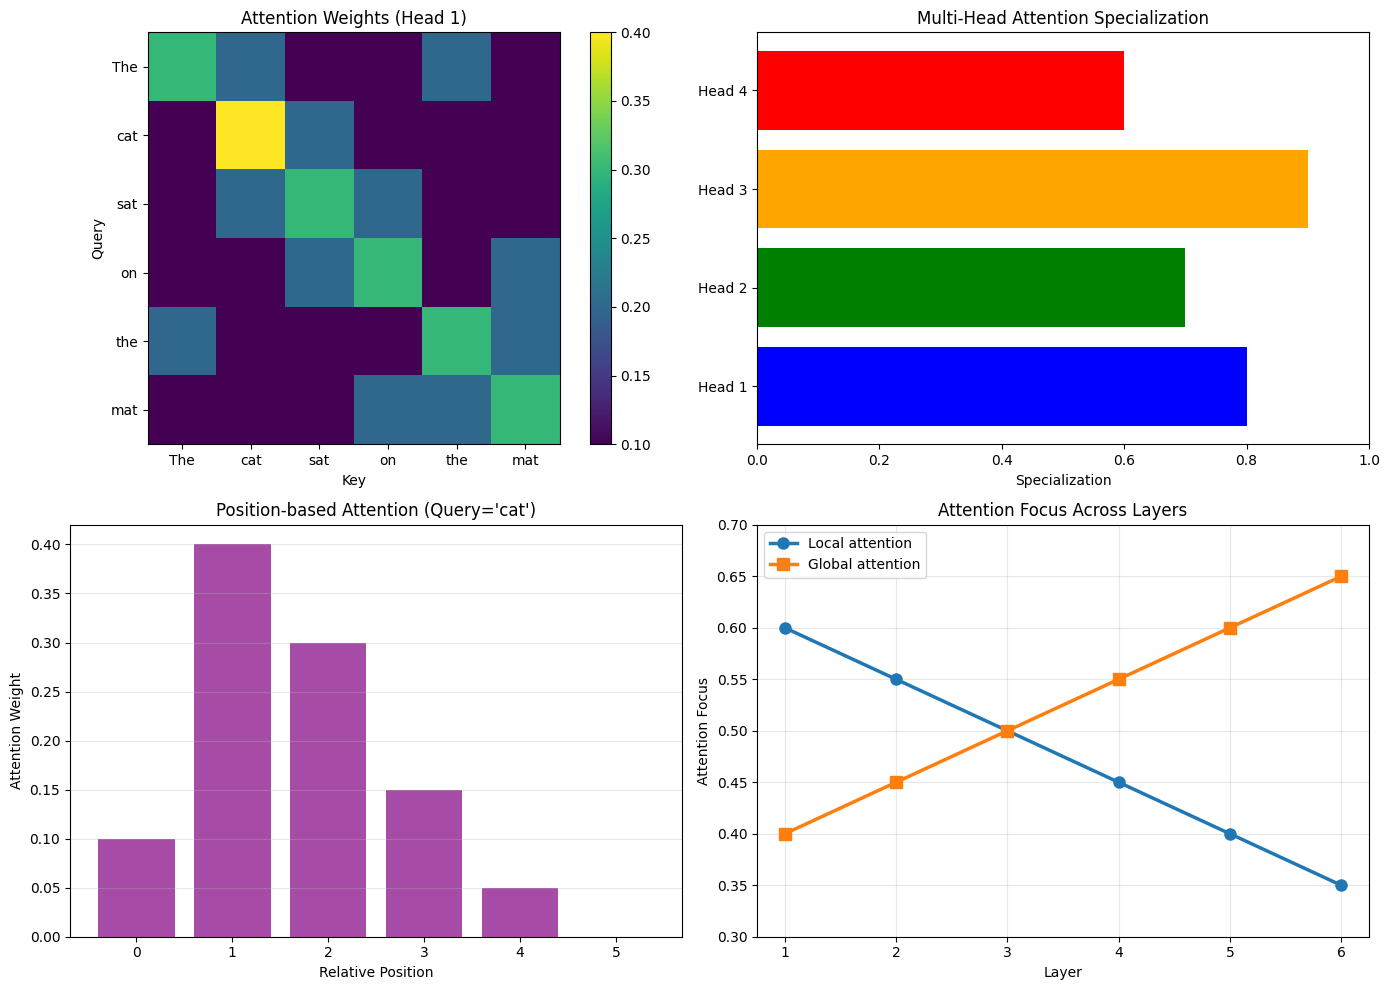

In [7]:
# Execute code with detailed step-by-step process
## 6. Attention Visualization

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Iterate through batches of data
# Simulated attention weights for first head
sentence = ['The', 'cat', 'sat', 'on', 'the', 'mat']
att_matrix = np.array([
    [0.3, 0.2, 0.1, 0.1, 0.2, 0.1],
    [0.1, 0.4, 0.2, 0.1, 0.1, 0.1],
    [0.1, 0.2, 0.3, 0.2, 0.1, 0.1],
    [0.1, 0.1, 0.2, 0.3, 0.1, 0.2],
    [0.2, 0.1, 0.1, 0.1, 0.3, 0.2],
    [0.1, 0.1, 0.1, 0.2, 0.2, 0.3]
])

im = axes[0, 0].imshow(att_matrix, cmap='viridis')
axes[0, 0].set_xticks(range(len(sentence)))
axes[0, 0].set_yticks(range(len(sentence)))
axes[0, 0].set_xticklabels(sentence)
axes[0, 0].set_yticklabels(sentence)
axes[0, 0].set_title('Attention Weights (Head 1)')
axes[0, 0].set_ylabel('Query')
axes[0, 0].set_xlabel('Key')
plt.colorbar(im, ax=axes[0, 0])

# Multi-head comparison
heads = ['Head 1', 'Head 2', 'Head 3', 'Head 4']
focus = ['Positions', 'Subject-Verb', 'Long-range', 'Adjacent']
axes[0, 1].barh(heads, [0.8, 0.7, 0.9, 0.6], color=['blue', 'green', 'orange', 'red'])
axes[0, 1].set_xlabel('Specialization')
axes[0, 1].set_title('Multi-Head Attention Specialization')
axes[0, 1].set_xlim([0, 1])

# Attention position (diagonal shift = position bias)
position = np.arange(6)
heads_attention = [0.1, 0.4, 0.3, 0.15, 0.05, 0]
axes[1, 0].bar(position, heads_attention, color='purple', alpha=0.7)
axes[1, 0].set_xlabel('Relative Position')
axes[1, 0].set_ylabel('Attention Weight')
axes[1, 0].set_title('Position-based Attention (Query=\'cat\')')
axes[1, 0].grid(True, alpha=0.3, axis='y')

# Attention across layers
layers = np.arange(1, 7)
loc_focus = [0.6, 0.55, 0.5, 0.45, 0.4, 0.35]
glob_focus = [0.4, 0.45, 0.5, 0.55, 0.6, 0.65]
axes[1, 1].plot(layers, loc_focus, marker='o', label='Local attention', linewidth=2.5, markersize=8)
axes[1, 1].plot(layers, glob_focus, marker='s', label='Global attention', linewidth=2.5, markersize=8)
axes[1, 1].set_xlabel('Layer')
axes[1, 1].set_ylabel('Attention Focus')
axes[1, 1].set_title('Attention Focus Across Layers')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].set_ylim([0.3, 0.7])

plt.tight_layout()
plt.show()


## Key Takeaways
- Attention computes weighted sum of values based on query-key similarity
- Scaled dot-product prevents large gradients
- Multi-head attention: multiple attention operations in parallel
- Self-attention attends within same sequence
- Cross-attention attends across sequences (encoder-decoder)
- Positional encoding: inject sequence position information
- Transformer blocks: attention + FFN + residuals + layer norm

## References
- [Attention is All You Need](https://arxiv.org/abs/1706.03762)